In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.getcwd())) 

import xarray as xr
import numpy as np
from matplotlib import colors, cm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import datetime

from turbulence_AUSCAT.auscat_plots import *
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import calendar

import glob

from scipy import stats
from xarray.groupers import SeasonResampler, SeasonGrouper
import os


import dask
from dask.distributed import Client
# request 14 cores 64GB


In [2]:
from turbulence_AUSCAT.cat_evaluation import combined_significance_table, time_sel_dict, calc_trend_table, select_resample_time
# combined_significance_table is very slow and not at all parallelised. Need to be smarter so it can be run on dask

In [3]:
mid_lat_slice = slice(-50,-25)
lon_slice = slice(90,195)
baseline_time_range = np.arange(1990,2009+1)
baseline_time_slice = slice("1990", "2009")


In [4]:
# ssp_colors = {"evaluation":"k",
#               "historical":"grey",
#               "ssp585":(149/255,27/255,30/255),
#               "ssp370":(231/255,29/255,37/255),
#               "ssp245":(247/255,148/255,32/255),
#               "ssp126":(23/255,60/255,102/255),
#               "ssp119":(0/255,173/255,207/255),}

In [4]:
list_evaluation = ['evaluation_BARRA-R_r1i1p1f1',
                  ]

list_historical = ['historical_ACCESS-CM2_r4i1p1f1', 
                   'historical_ACCESS-ESM1-5_r6i1p1f1',
                   'historical_CESM2_r11i1p1f1', 
                   'historical_CMCC-ESM2_r1i1p1f1',
                   'historical_EC-Earth3_r1i1p1f1',
                   'historical_MPI-ESM1-2-HR_r1i1p1f1',
                   'historical_NorESM2-MM_r1i1p1f1',
                  ]

list_ssp126 = [
                 'ssp126_ACCESS-CM2_r4i1p1f1',
                 'ssp126_ACCESS-ESM1-5_r6i1p1f1',
                 'ssp126_CESM2_r11i1p1f1',
                 'ssp126_CMCC-ESM2_r1i1p1f1',
                 'ssp126_EC-Earth3_r1i1p1f1',
                 'ssp126_MPI-ESM1-2-HR_r1i1p1f1',
                 'ssp126_NorESM2-MM_r1i1p1f1',
              ]

list_ssp370 = ['ssp370_ACCESS-CM2_r4i1p1f1',
                 'ssp370_ACCESS-ESM1-5_r6i1p1f1',
                 'ssp370_CESM2_r11i1p1f1',
                 'ssp370_CMCC-ESM2_r1i1p1f1',
                 'ssp370_EC-Earth3_r1i1p1f1',
                 'ssp370_MPI-ESM1-2-HR_r1i1p1f1',
                 'ssp370_NorESM2-MM_r1i1p1f1',
              ]

list_ssp585 = ['ssp585_ACCESS-CM2_r4i1p1f1',
                 'ssp585_EC-Earth3_r1i1p1f1']

list_future = list_ssp126 + list_ssp370 + list_ssp585

# start the calculations loops from here

In [5]:
turbulence_index = "TI1"
P=250

In [7]:
# make evaluation table
# Evaluate the models compared to BARRA-R for a baseline period of 1990 to 2009
from turbulence_AUSCAT.cat_evaluation import combined_significance_table

path=f"/scratch/v46/ls7238/CAT_turbulence"
outfile = f"{path}/{turbulence_index}/{P}hPa/evaluation_combined_tests_table_{turbulence_index}-{P}hPa.csv"

if  os.path.exists(outfile):
    print(f"File '{outfile}' already exists.")
else:
    with Client(threads_per_worker=4, n_workers=1) as client:
        combined_significance_table(turbulence_index, P, path=path)

File '/scratch/v46/ls7238/CAT_turbulence/TI1/250hPa/evaluation_combined_tests_table_TI1-250hPa.csv' already exists.


# Evaluate baseline period

In [9]:
filelist = glob.glob(f"/scratch/v46/ls7238/CAT_turbulence/{turbulence_index}/{P}hPa/freq-above-p99/{turbulence_index}-{P}hPa-monthly-freq-above-p99_AUS-15_*.nc")
ds = xr.open_mfdataset(filelist, 
                       combine="nested",
                       concat_dim="run",
                       join='outer', 
                       coords='different',
                      compat='no_conflicts')
ds = ds.assign_coords({"pressure":[P]})

CPU times: user 10.2 s, sys: 1.58 s, total: 11.8 s
Wall time: 2min 10s


PermissionError: [Errno 13] Permission denied: '/scratch/v46/gt3409/TI1/250hPa/Evaluation_TI1_250hPa_frequency_of_exceeding_p99_historical_annual_1990-2009.png'

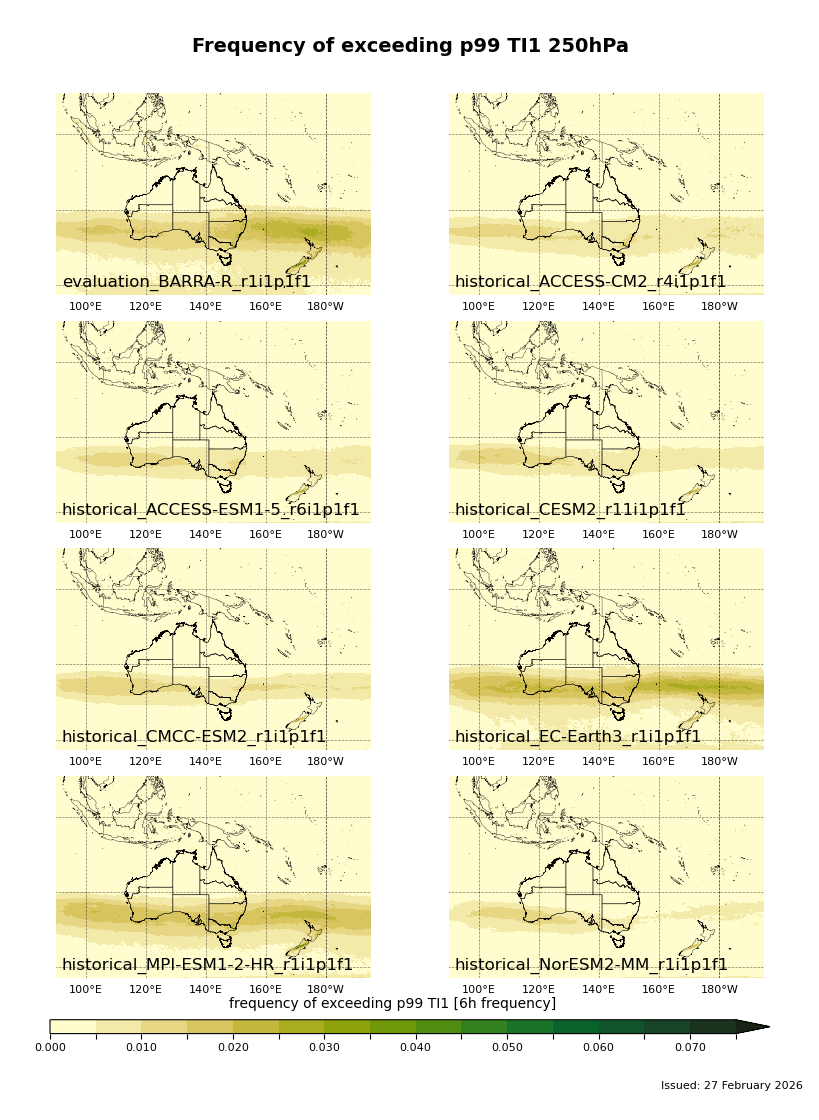

In [11]:
%%time
with Client(threads_per_worker=4, n_workers=1) as client:
    client
    ds_baseline_mapped = ds.isel({'pressure':0}).sel({"time":baseline_time_slice, 
                                                          # "lat":mid_lat_slice,
                                                          "lon": lon_slice}).resample({"time":"YE"}).mean()

    
    evaluate_model_map(ds_baseline_mapped, turbulence_index, P)
    evaluate_model_map_anom(ds_baseline_mapped, turbulence_index, P)

# Time series

In [10]:
%%time
# Dataset time series
# weighted for latitudes
weights = np.cos(np.deg2rad(ds[turbulence_index].lat))
weights.name = "weights"

ds_ts  = ds.sel({"lat":mid_lat_slice, 
                 "lon": lon_slice,
                 "run":list_evaluation+list_historical+list_future
                }).weighted(weights).mean(["lat", "lon"]).load()
ds_ts

CPU times: user 1min 22s, sys: 2min 21s, total: 3min 44s
Wall time: 1min 28s


<xarray.Dataset> Size: 296kB
Dimensions:  (time: 1464, run: 24)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1979-01-31 1979-02-28 ... 2100-12-31
  * run      (run) <U33 3kB 'evaluation_BARRA-R_r1i1p1f1' ... 'ssp585_EC-Eart...
Data variables:
    TI1      (run, time) float64 281kB nan nan nan ... 0.003429 0.003394

In [ ]:
# calculate table

outfile = f"/scratch/v46/ls7238/CAT_turbulence/{turbulence_index}/{P}hPa/Trend_table_{turbulence_index}_{P}hPa_Frequency_of_exceeding_p99.csv" 

if  os.path.exists(outfile):
    print(f"File '{outfile}' already exists.")
else:
    calc_trend_table(ds_ts, turbulence_index, P, outfile=outfile,)


File '/scratch/v46/gt3409/TI1/250hPa/Trend_table_TI1_250hPa_Frequency_of_exceeding_p99.csv' already exists.


In [12]:
window_size = 10

using ['historical_ACCESS-CM2_r4i1p1f1', 'historical_ACCESS-ESM1-5_r6i1p1f1', 'historical_CESM2_r11i1p1f1', 'historical_CMCC-ESM2_r1i1p1f1', 'historical_EC-Earth3_r1i1p1f1', 'historical_MPI-ESM1-2-HR_r1i1p1f1', 'historical_NorESM2-MM_r1i1p1f1']
Saved /scratch/v46/gt3409/TI1/250hPa/Timeseries_TI1_250hPa_Frequency_of_exceeding_p99_over_time_annual_rolling10y.png
using ['historical_ACCESS-CM2_r4i1p1f1', 'historical_ACCESS-ESM1-5_r6i1p1f1', 'historical_CESM2_r11i1p1f1', 'historical_CMCC-ESM2_r1i1p1f1', 'historical_EC-Earth3_r1i1p1f1', 'historical_MPI-ESM1-2-HR_r1i1p1f1', 'historical_NorESM2-MM_r1i1p1f1']
Saved /scratch/v46/gt3409/TI1/250hPa/Timeseries_TI1_250hPa_Frequency_of_exceeding_p99_over_time_annual_rolling1y.png


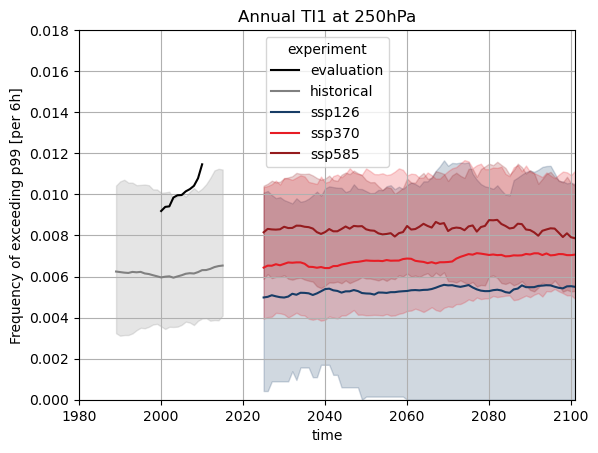

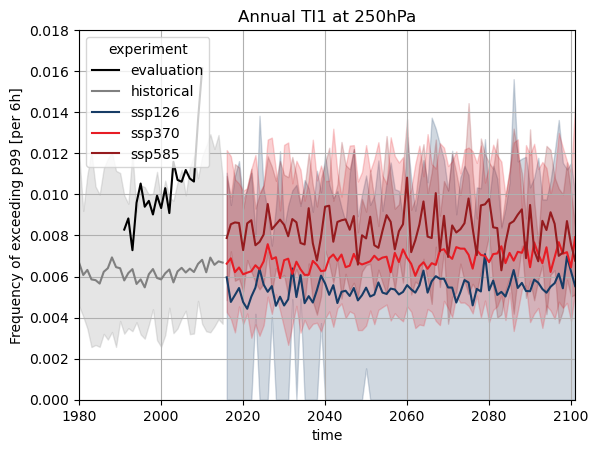

In [13]:
plot_timeseries_annual(ds_ts, turbulence_index, P, window_size, ymax=0.018)
plot_timeseries_annual(ds_ts, turbulence_index, P, window_size=1, ymax=0.018)


using ['historical_ACCESS-CM2_r4i1p1f1', 'historical_ACCESS-ESM1-5_r6i1p1f1', 'historical_CESM2_r11i1p1f1', 'historical_CMCC-ESM2_r1i1p1f1', 'historical_EC-Earth3_r1i1p1f1', 'historical_MPI-ESM1-2-HR_r1i1p1f1', 'historical_NorESM2-MM_r1i1p1f1']
using ['historical_ACCESS-CM2_r4i1p1f1', 'historical_ACCESS-ESM1-5_r6i1p1f1', 'historical_CESM2_r11i1p1f1', 'historical_CMCC-ESM2_r1i1p1f1', 'historical_EC-Earth3_r1i1p1f1', 'historical_MPI-ESM1-2-HR_r1i1p1f1', 'historical_NorESM2-MM_r1i1p1f1']
Saved /scratch/v46/gt3409/TI1/250hPa/Timeseries_TI1_250hPa_Frequency_of_exceeding_p99_over_time_6Mseason_rolling10y.png
DJF
using ['historical_ACCESS-CM2_r4i1p1f1', 'historical_ACCESS-ESM1-5_r6i1p1f1', 'historical_CESM2_r11i1p1f1', 'historical_CMCC-ESM2_r1i1p1f1', 'historical_EC-Earth3_r1i1p1f1', 'historical_MPI-ESM1-2-HR_r1i1p1f1', 'historical_NorESM2-MM_r1i1p1f1']
MAM
using ['historical_ACCESS-CM2_r4i1p1f1', 'historical_ACCESS-ESM1-5_r6i1p1f1', 'historical_CESM2_r11i1p1f1', 'historical_CMCC-ESM2_r1i1p1f

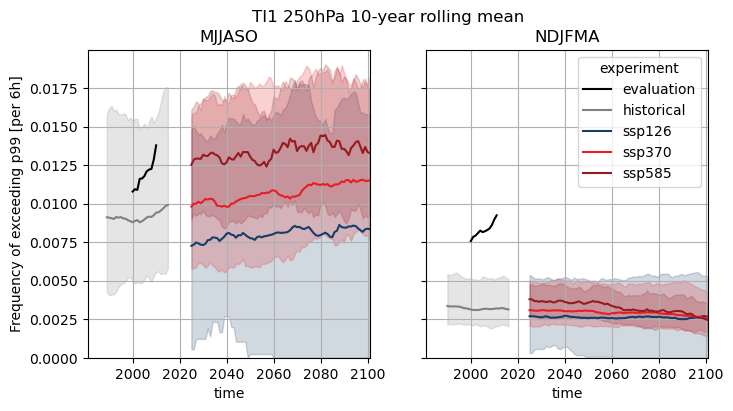

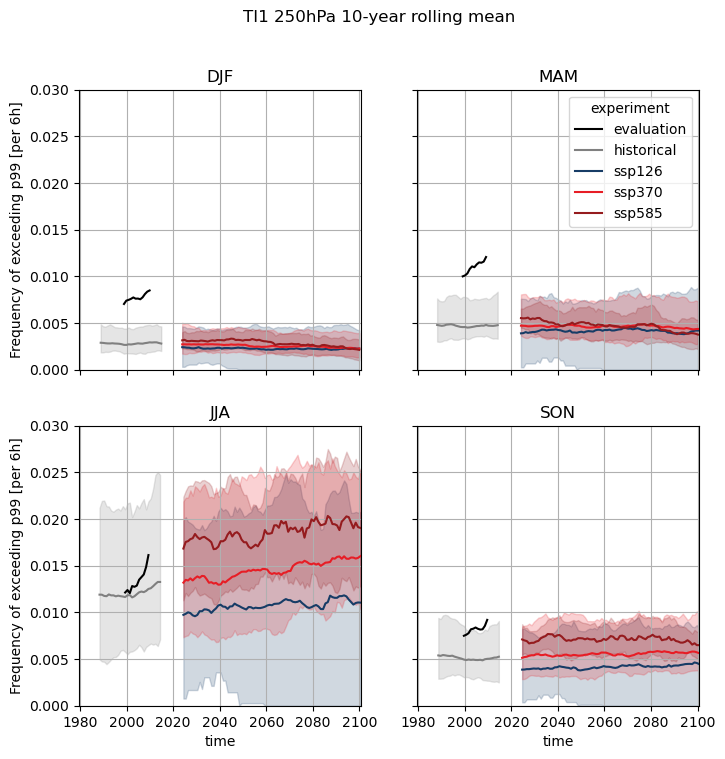

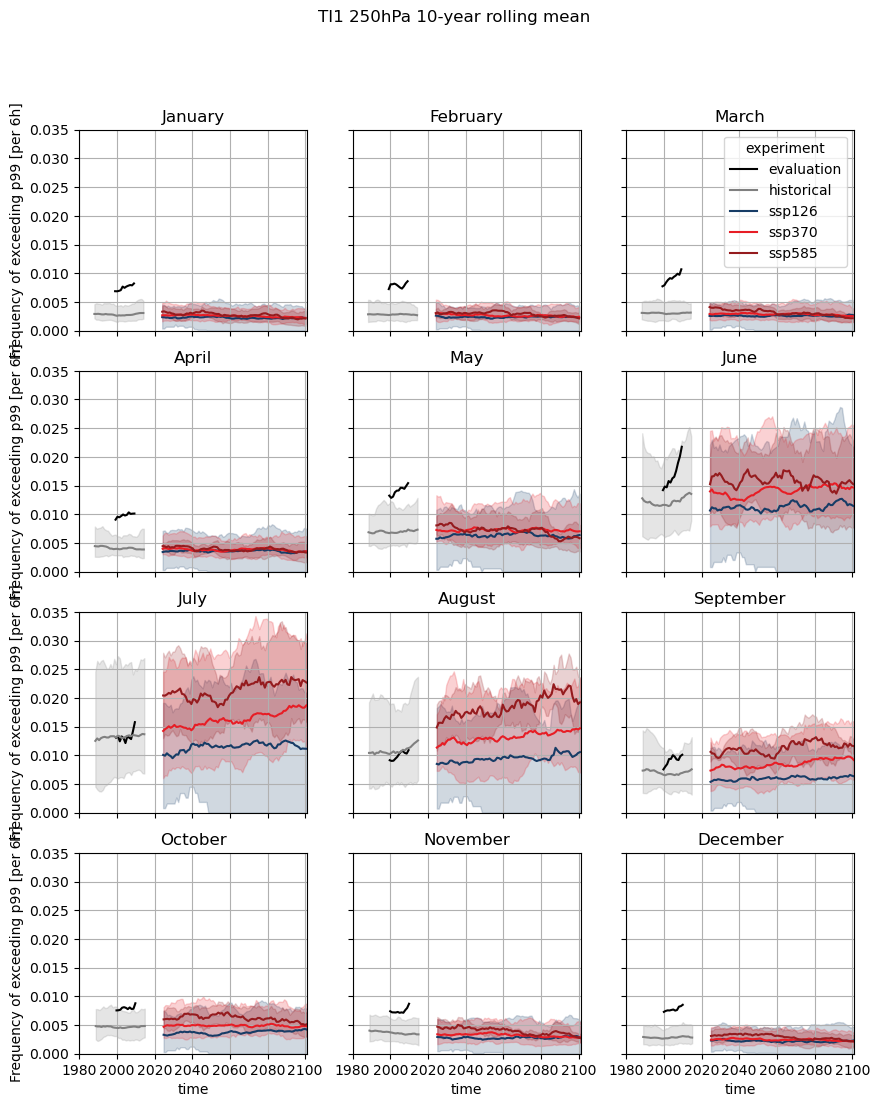

In [14]:
plot_timeseries_coolwarmseason(ds_ts, turbulence_index, P, window_size, ymax=None)   
plot_timeseries_season(ds_ts, turbulence_index, P, window_size, ymax=0.03)
plot_timeseries_month(ds_ts, turbulence_index, P, window_size, ymax=0.035)

# maps

In [ ]:
evaluation = list_evaluation[0]
filelist = [f"/scratch/v46/ls7238/CAT_turbulence/{turbulence_index}/{P}hPa/freq-above-p99/{turbulence_index}-{P}hPa-monthly-freq-above-p99_AUS-15_{run}_BOM_BARPA-R_v1-r1_6hr.nc" 
                        for run in [evaluation] + list_historical]
ds = xr.open_mfdataset(filelist,
                      concat_dim="run",
                      combine="nested",
                      join="outer",
                      coords='different',
                      compat='no_conflicts').sel({"lon":lon_slice, "time": baseline_time_slice})

ds_hist = ds.sel({"run":list_historical})
ds=ds.sel({"run":evaluation}).load()
ds_eval=ds


Saved /scratch/v46/gt3409/TI1/250hPa/Evaluation_TI1_250hPa_Frequency_of_exceeding_p99_evaluation_annual_1990-2009.png
Saved /scratch/v46/gt3409/TI1/250hPa/Evaluation_TI1_250hPa_Frequency_of_exceeding_p99_historical_6Mseason_1990-2009.png
Saved /scratch/v46/gt3409/TI1/250hPa/Evaluation_TI1_250hPa_Frequency_of_exceeding_p99_historical_season_1990-2009.png
Saved /scratch/v46/gt3409/TI1/250hPa/Evaluation_TI1_250hPa_Frequency_of_exceeding_p99_historical_month_1990-2009.png
CPU times: user 27.7 s, sys: 4.15 s, total: 31.9 s
Wall time: 31.9 s


(<Figure size 800x800 with 14 Axes>,
 array([[<GeoAxes: >, <GeoAxes: >, <GeoAxes: >],
        [<GeoAxes: >, <GeoAxes: >, <GeoAxes: >],
        [<GeoAxes: >, <GeoAxes: >, <GeoAxes: >],
        [<GeoAxes: >, <GeoAxes: >, <GeoAxes: >]], dtype=object))

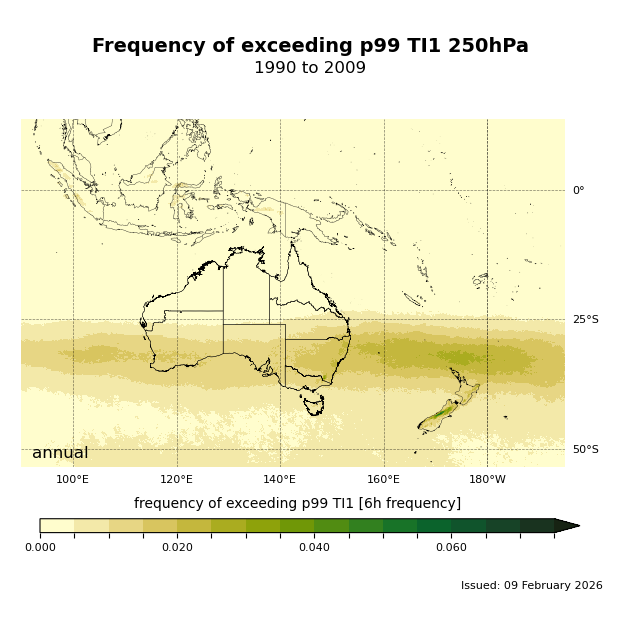

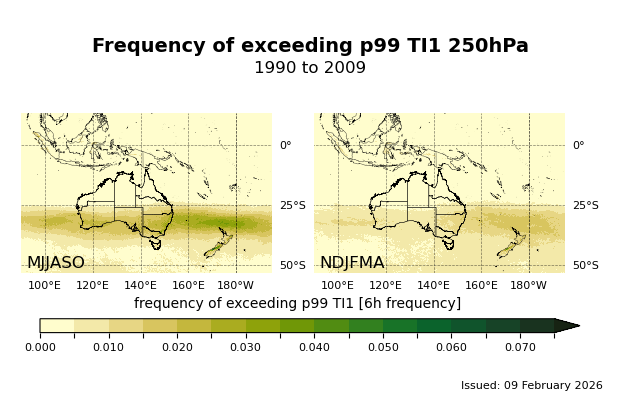

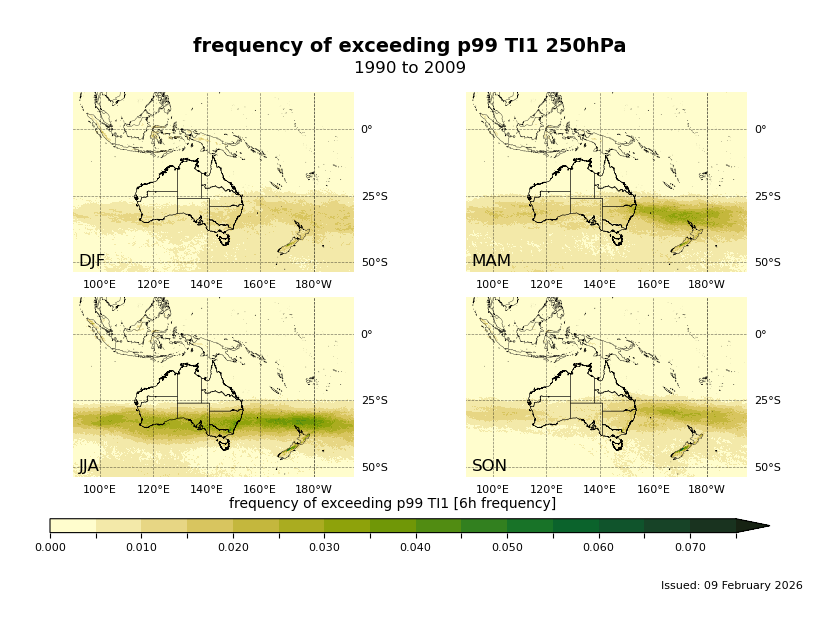

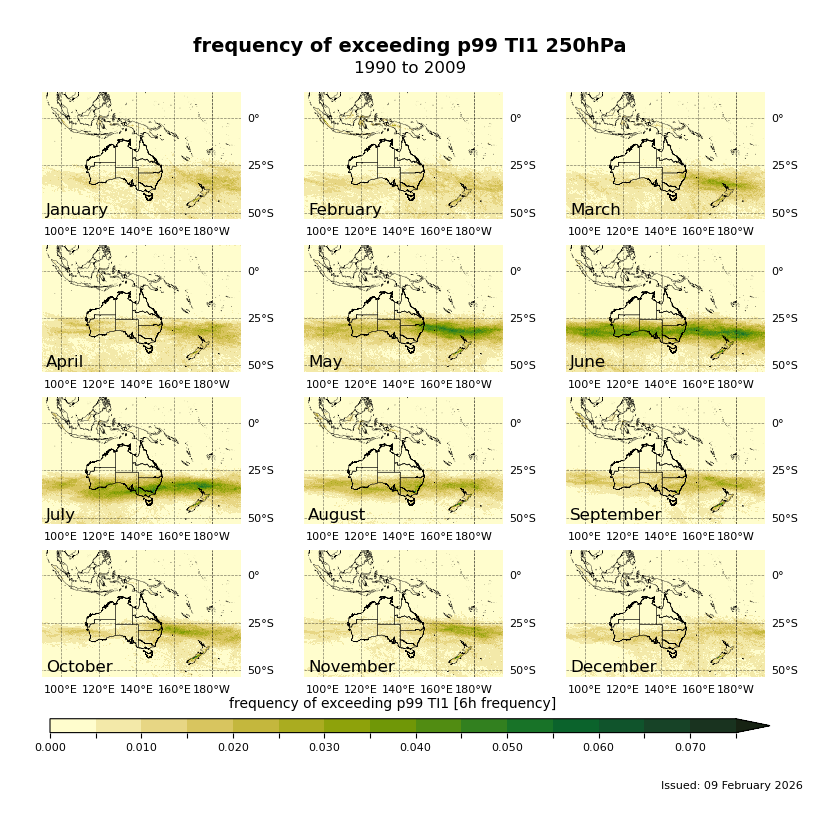

In [16]:
%%time
# annual
plot_baseline_ann(ds_eval, turbulence_index, P, ticks_max=0.08)   
plot_baseline_coolwarmseason(ds_eval, turbulence_index, P,ticks_max=0.08)
plot_baseline_season(ds_eval, turbulence_index, P,ticks_max=0.08)
plot_baseline_months(ds_eval, turbulence_index, P,ticks_max=0.08)

# time evolution of mapped indices


In [ ]:
%%time
with Client(threads_per_worker=5, n_workers=2) as client:
    plt.close()
    time_slices = [("2015", "2035"), 
                  ("2040", "2060"),
                  ("2080", "2100"),
                  ]
    # for turbulence_index in ["VWS", "windspeed"]:
    #     for P in ["200", "250"]:
    for time_selection in ["MJJASO", "annual",]:
        for experiment in ["ssp126", "ssp370", "ssp585"]:
            if experiment == "ssp585":
                # because there are only two
                all_agree_except = 0
            else:
                all_agree_except = 1
            outfile = f"/scratch/v46/ls7238/CAT_turbulence/{turbulence_index}/{P}hPa/Future_decades_{turbulence_index}_{P}hPa_change_in_frequency_of_exceeding_p99_{experiment}_{time_selection}_3timeslices.png"
            if  os.path.exists(outfile):
                print(f"File '{outfile}' already exists.")
                continue
            try:
                plot_futures(time_selection=time_selection, 
                             turbulence_index=turbulence_index,
                                 time_slices=time_slices,
                                 experiment=experiment, 
                                 all_agree_except=all_agree_except, 
                                 save_fig=True,
                                 outfile = outfile,
                                 zonal_plots=True,
                                 ticks_max=0.02,
                                )
            except:
                print(f"problem making '{outfile}'.")


File '/scratch/v46/gt3409/TI1/250hPa/Future_decades_TI1_250hPa_change_in_frequency_of_exceeding_p99_ssp126_MJJASO_3timeslices.png' already exists.
File '/scratch/v46/gt3409/TI1/250hPa/Future_decades_TI1_250hPa_change_in_frequency_of_exceeding_p99_ssp370_MJJASO_3timeslices.png' already exists.
File '/scratch/v46/gt3409/TI1/250hPa/Future_decades_TI1_250hPa_change_in_frequency_of_exceeding_p99_ssp585_MJJASO_3timeslices.png' already exists.
problem making '/scratch/v46/gt3409/TI1/250hPa/Future_decades_TI1_250hPa_change_in_frequency_of_exceeding_p99_ssp126_annual_3timeslices.png'.
problem making '/scratch/v46/gt3409/TI1/250hPa/Future_decades_TI1_250hPa_change_in_frequency_of_exceeding_p99_ssp370_annual_3timeslices.png'.
problem making '/scratch/v46/gt3409/TI1/250hPa/Future_decades_TI1_250hPa_change_in_frequency_of_exceeding_p99_ssp585_annual_3timeslices.png'.
CPU times: user 80.7 ms, sys: 52.2 ms, total: 133 ms
Wall time: 1.06 s


In [ ]:
# %%time
with Client(threads_per_worker=12, n_workers=1) as client:
    # for turbulence_index in ["VWS", "windspeed"]:
    #     for P in ["200", "250"]:
    combined_significance_table_file= (f"/scratch/v46/ls7238/CAT_turbulence/{turbulence_index}/{P}hPa/evaluation_combined_tests_table_{turbulence_index}-{P}hPa.csv")
    if  os.path.exists(combined_significance_table_file):
        print(f"File '{combined_significance_table_file}' already exists.")
    else:
        combined_significance_table(turbulence_index, P,)
        print(f"Made '{combined_significance_table_file}'")


File '/scratch/v46/gt3409/TI1/250hPa/evaluation_combined_tests_table_TI1-250hPa.csv' already exists.
